In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/tf/ProjectGabriel/pilca")

import numpy as np
import pandas as pd
from lightcurve_fitting import models, filters, lightcurve
import matplotlib.pyplot as plt
import matplotlib as mpl
import importlib
from utils.utils import load_lc
from utils.utils import light_curve_plot
import torch
import utils.torchphysics as tp
import utils.utils as ut
# import lc
import os
torch.set_default_dtype(torch.float64)



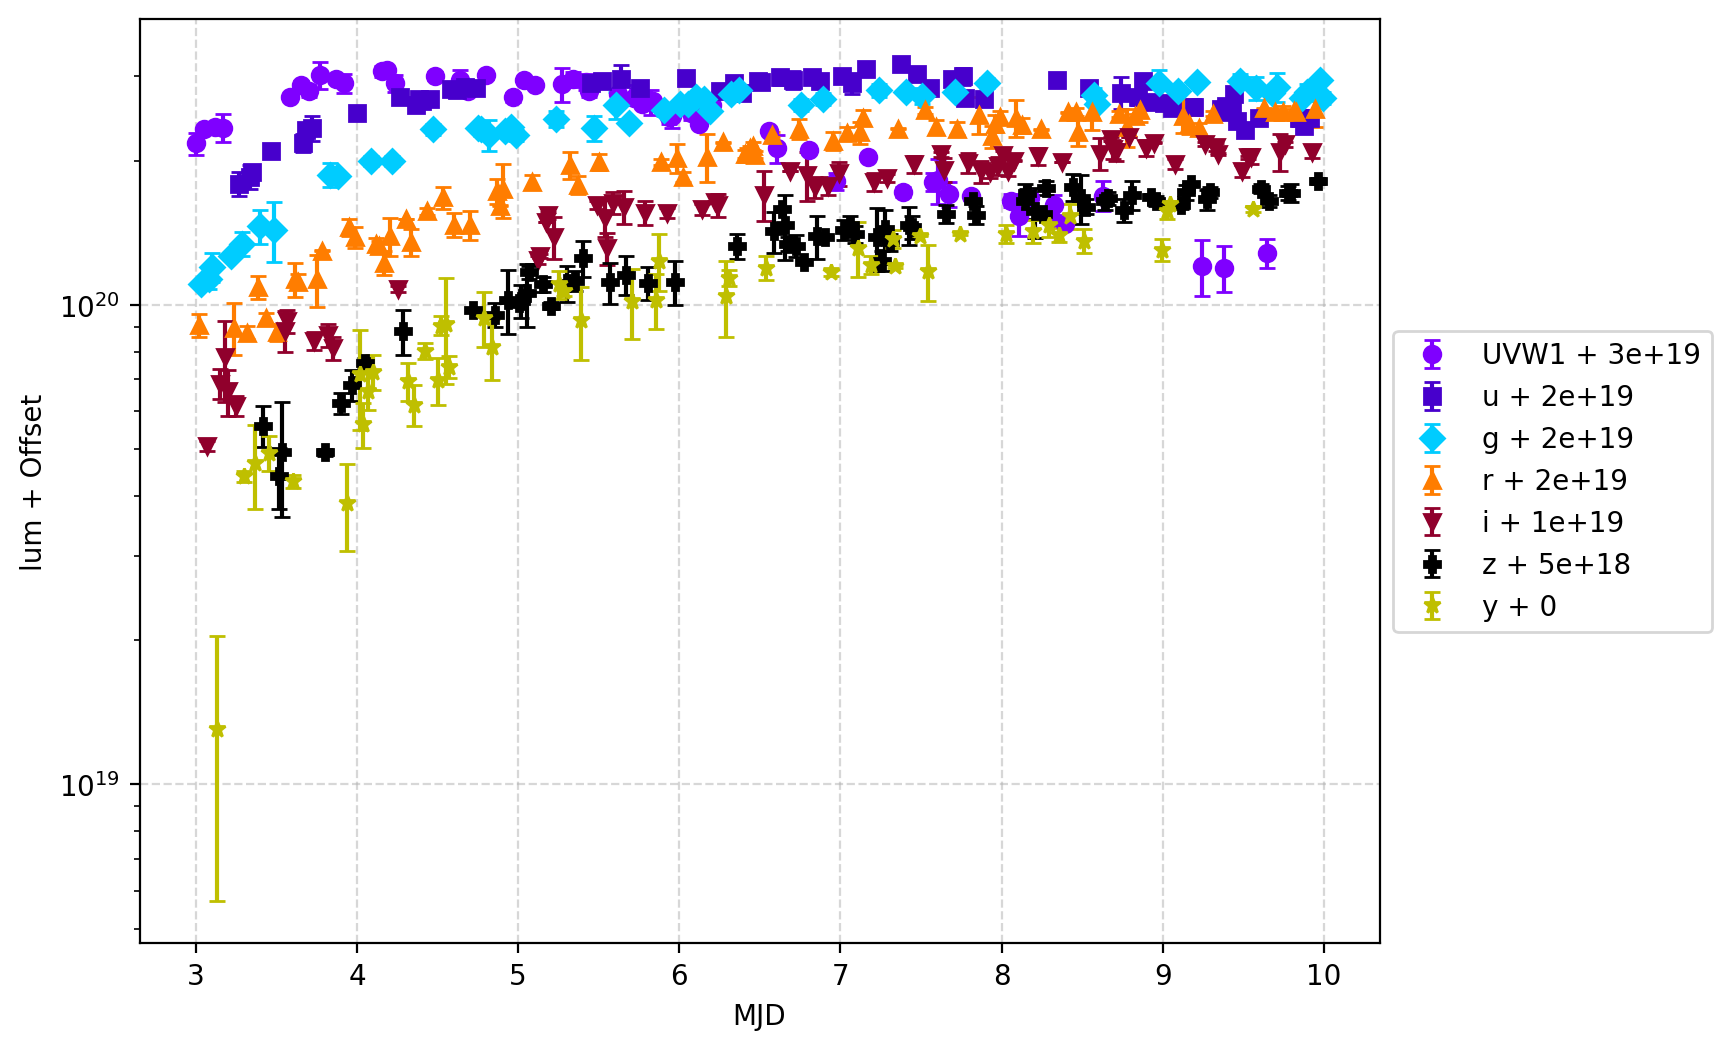

In [14]:
# --- define cumulative filter sets (z → UV) ---

all_filters = ["z", "y", "i", "r", "g", "u", "uvw1"]  # from red to UV
mjd_array = np.linspace(3, 13, 600)


filter_combinations = [all_filters[:i+1] for i in range(len(all_filters))]

max_days = 10
time_spans = np.arange(1, max_days + 1)  # [1, 2, ..., 10]

model_parameters = [1.2, 1.8, 3.0, 2.5]

# --- setup light curve builder ---
builder = ut.LCBuilder(
    model_name="sc4",
    model_parameters=model_parameters,
    model_units=[1,1,1,1],
    seed=42
)

lc = builder.build_sim_lc(
    mjd_array=mjd_array,
    filters_list=all_filters,  # full set
    redshift=0.00526,
    dlum_factor=1e-1/2,
    dm=31.1,
    dL=19.,
    dLerr=2.9
)
light_curve_plot(lc.where(MJD_max=10), offset = .5, ycol="lum")

MW extinction not applied to filter w
host extinction not applied to filter w
MW extinction not applied to filter y
host extinction not applied to filter y


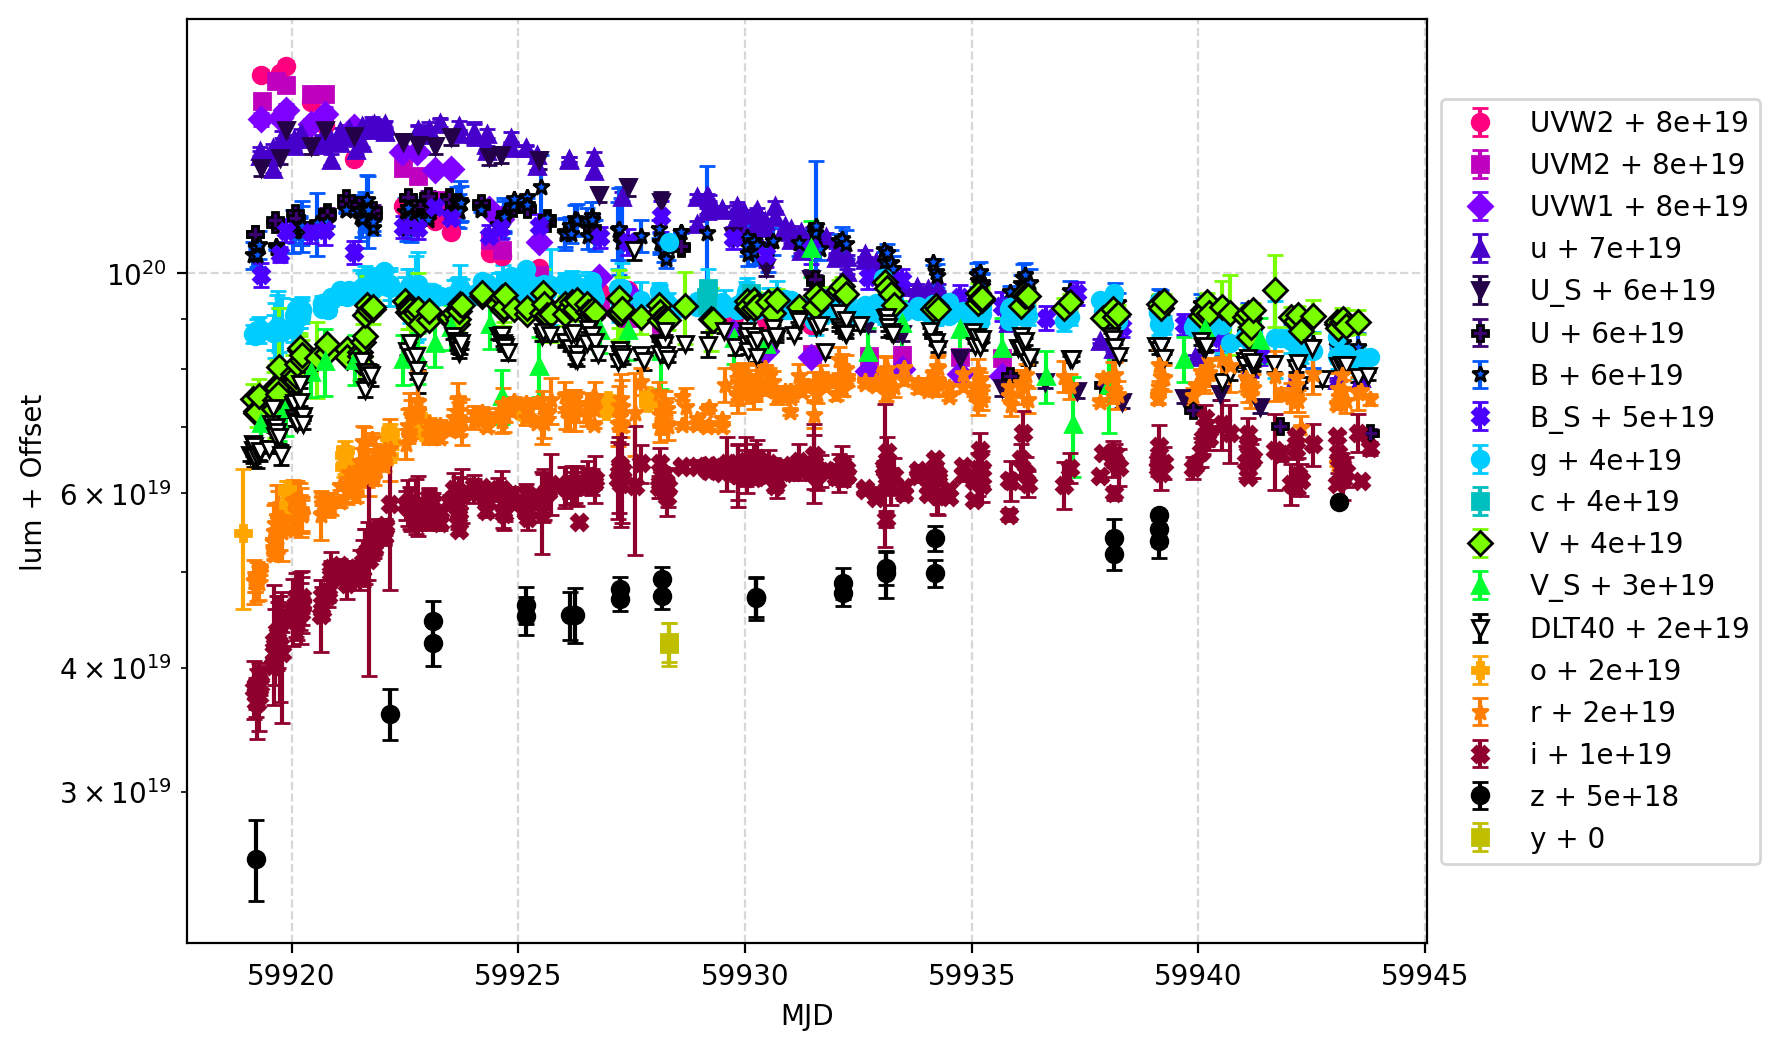

In [19]:
lc_dir = os.path.join("../data/2022acko", "2022acko_total.dat")
lc = load_lc(lc_dir=lc_dir)
lc.calcAbsMag()
lc.calcLum()
light_curve_plot(lc[lc["MJD"]<np.min(lc["MJD"])+25], ycol="lum")
